# **PicassoPy Workshop --> Test case: cpv 2024-08-21**
---


- Folder for data `test_case_data` -> download separately
- Folder for configs `test_case_config`


## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import argparse
import datetime
import logging
from pathlib import Path
import numpy as np

sys.path.append('../')
import ppcpy
import ppcpy.io.loadConfigs as loadConfigs
import ppcpy.io.readPollyRawData as readPollyRawData
import ppcpy.interface.picassoProc as picassoProc
import ppcpy.misc.helper as helper
import ppcpy.misc.startscreen as startscreen
from ppcpy.io.write2nc import write_channelwise_2_nc_file, write2nc_file, write_profile2nc_file

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab20.colors)
from ppcpy.visualization.python_colormap import load_colormap, target_classification_colormap

# Define cmaps:
labivew_cmap = load_colormap('labview')
labivew_cmap.set_bad(color='white')
tc_cmap = target_classification_colormap()

## Defining Script Inputs

- The parameters `args.device`, `args.timestamp`, `args.picasso_config_file`, `args.level0_file_to_process`, need to be manually specified per case.
- The parameter `DATABASE_PATH` is the path to the database used for storing the retrieved calibration constants

In [3]:
## For purpose of the notebook mimic the argparse interface
from types import SimpleNamespace
args = SimpleNamespace()

## The used device and time of measurement
args.device = 'pollyxt_cpv'
args.timestamp = '20240821'
dt = datetime.datetime.strptime(args.timestamp, "%Y%m%d")

## The used config file
args.picasso_config_file = "test_case_config/pollynet_processing_chain_config_test.json"

## The data file to use
args.level0_file_to_process = f"test_case_data/{dt:%Y_%m_%d_%a}_CPV_00_00_01.nc"


## Database path
DATABASE_PATH = "PicassoPyDatabase.db"

In [4]:
startscreen.startscreen()

      ____  _                            ____           ___ ____ 
     / __ \(_)________ _______________  / __ \__  __   <  // __ \
    / /_/ / / ___/ __ `/ ___/ ___/ __ \/ /_/ / / / /   / // / / /
   / ____/ / /__/ /_/ (__  |__  ) /_/ / ____/ /_/ /   / // /_/ / 
  /_/   /_/\___/\__,_/____/____/\____/_/    \__, /   /_(_)____/  
                                           /____/                


## Load Data and Config-files

Loads data and information from the config files into the following three dictionaries:
- `picasso_config_dict`: Paths and other information stored in the picasso-config file
- `polly_config_dict`: Configuration variables from the merged polly-config and polly-default files
- `rawdata_dict`: Measurement data and information extracted from the level0 file

In [5]:
## Path to default Picasso config file
picasso_default_config_file = Path(
    helper.detect_path_type(Path.cwd().parent), 'ppcpy', 'config', 'pollynet_processing_chain_config.json')

## Load Picasso config file
picasso_config_dict = loadConfigs.loadPicassoConfig(args.picasso_config_file, picasso_default_config_file)

## load polly config file
polly_config_array = loadConfigs.readPollyNetConfigLinkTable(
    picasso_config_dict['pollynet_config_link_file'], timestamp=args.timestamp, device=args.device
)
polly_config_dict = loadConfigs.getPollyConfigfromArray(
    polly_config_array, picasso_config_dict
)

## Load level0-data file
rawfile_fullname = args.level0_file_to_process
rawfile = helper.detect_path_type(rawfile_fullname)
rawdata_dict = readPollyRawData.readPollyRawData(rawfile)

2026-08-13 17:22:17,225 - INFO - picasso_default_config_file: c:\Users\buholdt\Documents\PicassoPy\ppcpy\config\pollynet_processing_chain_config.json
2026-08-13 17:22:17,226 - INFO - picasso_config_file: test_case_config/pollynet_processing_chain_config_test.json
2026-08-13 17:22:17,227 - INFO - pollynet_config_link_file: test_case_config/pollynet_processing_chain_config_links.xlsx


2026-08-13 17:22:17,539 - INFO - polly_default_config_file: c:\Users\buholdt\Documents\PicassoPy\ppcpy\config\polly_global_config.json
2026-08-13 17:22:17,541 - INFO - polly_config_file: test_case_config\pollyxt_cpv_config_20230927.json
2026-08-13 17:22:17,542 - INFO - keys default/template file, but not in specific file {'colormap_basic', 'yLim_cloudinfo', 'bgCorRangeIndxLow', 'overlapFile_532_total_FR', 'min_atten_par_beta_1064', 'isParallel', 'polCaliEtaStd355', 'overlapFile_355_total_FR', 'clear_thres_par_beta_1064', 'flagUseTheoreticalMDR', 'cloud_thres_par_beta_1064', 'zLim_NR_RCS_387', 'zLim_FR_RCS_407', 'depol_cal_time_fixed_p_start', 'zLim_VolDepol_532', 'droplet_thres_par_depol', 'ice_thres_par_depol', 'logbookPath', 'search_cloud_above', 'refH_FR_1064', 'yLim_all_profiles_high_range', 'unspheroid_thres_par_depol', 'minSNR_4_sigNorm', 'refH_FR_532', 'depol_cali_mode', 'polCaliEta355', 'depol_cal_time_fixed_p_end', 'xLim_Profi_LR', 'volDepolerror1064', 'maxCloudSearchHeight', 

## Initialize PicassoProc object

PicassoProc is the main object in PicassoPy, and is responsible for running all processes included and storing the data.

In [6]:
## Initialize PicassoProc
data_cube = picassoProc.PicassoProc(rawdata_dict, polly_config_dict, picasso_config_dict)

In [7]:
## reset date if date in filename differs date within nc-file 
data_cube.reset_date_infile()

## checking for correct measurement shots
data_cube.check_for_correct_mshots()

## setting channelTags
data_cube.setChannelTags()

## check for correct date in nc-file
data_cube.reset_date_infile()

2026-08-13 17:22:20,334 - INFO - date consistency-check... 
2026-08-13 17:22:20,335 - INFO - ... date in nc-file equals date of filename
2026-08-13 17:22:20,337 - INFO - ChannelLabels: ['FR-total-355 nm', 'FR-cross-355 nm', 'FR-387 nm', 'FR-407 nm', 'FR-total-532 nm', 'FR-cross-532 nm', 'FR-607 nm', 'FR-total-1064 nm', 'NR-total-532 nm', 'NR-607 nm', 'NR-total-355 nm', 'NR-387 nm', 'DFOV', '1058', '1064s', 'none']
2026-08-13 17:22:20,337 - WARNING - removed none tag from channel list [15]
2026-08-13 17:22:20,338 - INFO - date consistency-check... 
2026-08-13 17:22:20,339 - INFO - ... date in nc-file equals date of filename


## Preprocessing & Saturation Detection

The preprocessing includes the following processes:
- Deadtime correction
- Background correction
- SNR claculations
- Flagging of data
- Range correction

In [8]:
## Perform preprocessing, this includes Dead-time correction, Background correction, and Range correction
data_cube.preprocessing(collect_debug=True)

2026-08-13 17:22:20,381 - INFO - Preprocessing ...
2026-08-13 17:22:20,382 - INFO - ... time conversion
2026-08-13 17:22:20,387 - WARNING - ... mShots not constant min 0 max 2999
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\preprocess\pollyPreprocess.py:507: RuntimeWarning: invalid value encountered in divide
  PCR = (c * signal)/(2 * hRes * mShots[:, np.newaxis, :])
2026-08-13 17:22:26,451 - INFO - ... calculate dead-time corrected signal
2026-08-13 17:22:26,454 - INFO - ... Deadtime-correction (Mode: 1)
2026-08-13 17:22:45,798 - INFO - ... calculate background corrected signal
2026-08-13 17:22:45,800 - INFO - ... removing background from signal
2026-08-13 17:22:50,829 - INFO - ... height bin calculations
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\preprocess\pollyPreprocess.py:378: UserWarning: no explicit representation of timezones available for np.datetime64
  data_dict['time64'] = np.array([np.datetime64(t) for t in mTime_obj])
2026-08-13 17:22:51,256 - INFO - ... 

In [9]:
## Save high resolution signal-to-noise ratio, background, and range corrected signal
write_channelwise_2_nc_file(data_cube=data_cube, prod_ls=['SNR', 'BG', 'RCS'])

2026-08-13 17:23:04,091 - INFO - saving product: SNR
2026-08-13 17:23:04,292 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_SNR.nc
2026-08-13 17:23:24,901 - INFO - saving product: BG
2026-08-13 17:23:25,015 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_BG.nc
2026-08-13 17:23:25,049 - INFO - saving product: RCS
2026-08-13 17:23:25,154 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_RCS.nc


In [10]:
## Display available channels
data_cube.channel_dict

{0: 'FR-total-355 nm',
 1: 'FR-cross-355 nm',
 2: 'FR-387 nm',
 3: 'FR-407 nm',
 4: 'FR-total-532 nm',
 5: 'FR-cross-532 nm',
 6: 'FR-607 nm',
 7: 'FR-total-1064 nm',
 8: 'NR-total-532 nm',
 9: 'NR-607 nm',
 10: 'NR-total-355 nm',
 11: 'NR-387 nm',
 12: 'DFOV',
 13: '1058',
 14: '1064s'}

In [11]:
## Detect and flag saturated signal
data_cube.SaturationDetect()

2026-08-13 17:23:48,036 - INFO - Saturation detection ...
2026-08-13 17:23:48,037 - INFO - Saturation detection


### Plot Example: Set correct first range bin

The config variable `first_range_gate_index` should indicate the bin at which the signal is reset to 0 after the initial laser puls. This usally occurse around bin 252.

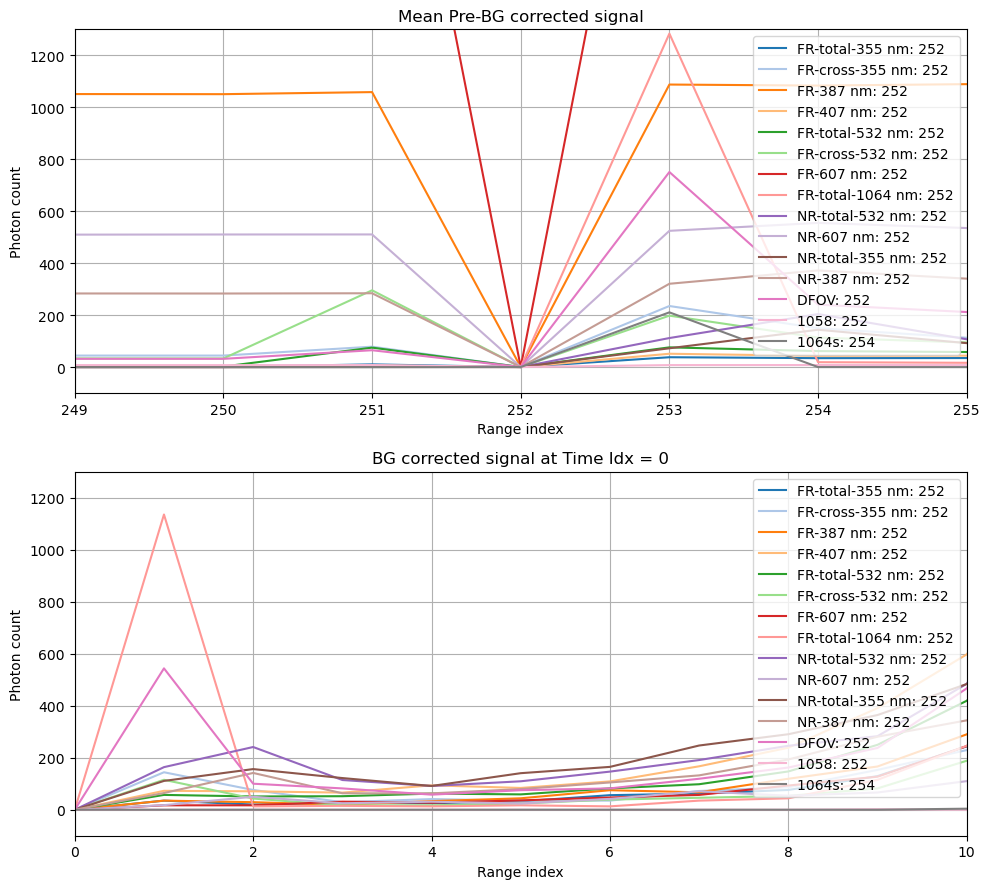

In [12]:
TimeIdx = 0
fig, ax = plt.subplots(2, 1, figsize=(10, 9))
for i in range(len(data_cube.channel_dict)):
    ax[0].plot(
        np.nanmean(data_cube.retrievals_highres['preproSignal'][:, :, i], axis=0), 
        label=data_cube.channel_dict[i]+f": {data_cube.polly_config_dict['first_range_gate_indx'][i]}"
    )
    ax[1].plot(
        data_cube.retrievals_highres['sigBGCor'][TimeIdx, :, i], 
        label=data_cube.channel_dict[i]+f": {data_cube.polly_config_dict['first_range_gate_indx'][i]}"
    )
ax[0].set_xlabel('Range index')
ax[0].set_ylabel('Photon count')
ax[0].set_xlim(249, 255)
ax[0].set_ylim(-100, 1300)
ax[0].grid()
ax[0].legend(loc="upper right")
ax[0].set_title("Mean Pre-BG corrected signal")
ax[1].set_xlabel('Range index')
ax[1].set_ylabel('Photon count')
ax[1].set_xlim(0, 10)
ax[1].set_ylim(-100, 1300)
ax[1].grid()
ax[1].legend(loc="upper right")
ax[1].set_title(f"BG corrected signal at Time Idx = {TimeIdx}")
fig.tight_layout()

### Plot example: Checking background levels

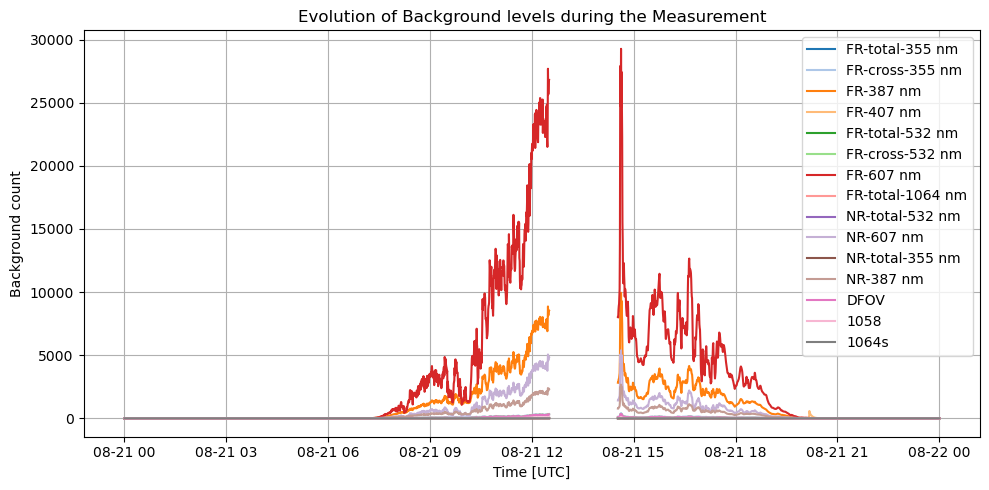

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(data_cube.channel_dict)):
    ax.plot(
        data_cube.retrievals_highres['time64'],
        data_cube.retrievals_highres['BG'][:, i], 
        label=data_cube.channel_dict[i]
    )
ax.set_xlabel('Time [UTC]')
ax.set_ylabel('Background count')
ax.grid()
ax.legend()
ax.set_title("Evolution of Background levels during the Measurement")
fig.tight_layout()

### Plot example: Range corrected signal

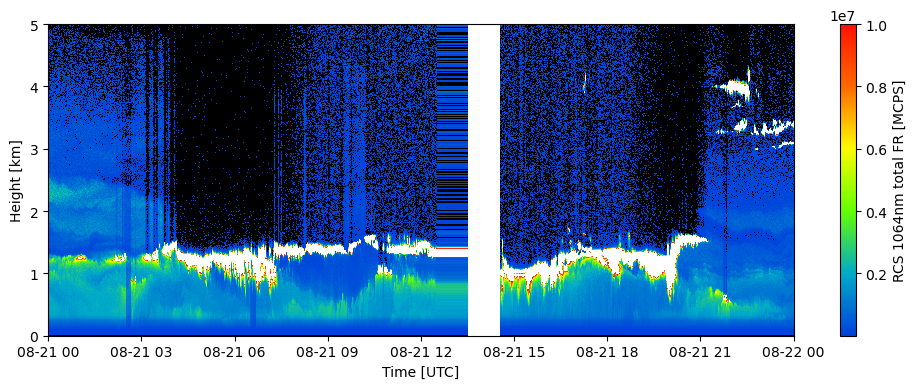

In [14]:
wv, t, tel = 1064, 'total', 'FR'

fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    np.squeeze(data_cube.retrievals_highres['RCS'][:, :, data_cube.gf(wv, t, tel)]).T,
    shading='nearest',
    cmap=labivew_cmap,
    vmin=5, vmax=1e7
)
cbar = fig.colorbar(pcmesh)
cbar.set_label(f"RCS {wv}nm {t} {tel} [MCPS]")
ax.set_xlabel('Time [UTC]')
ax.set_ylabel('Height [km]')
ax.set_ylim(0, 5)
fig.tight_layout()

## Depol Calibration


- Depol. calibration constants (DC) are retrieved at each depol. calibration period included in the data
- All retrieved DCs are stored in a dedicated database
- The optimal retrieved DC, ie. the one with the lowest standard deviation (std) is used for the processing
- If no DCs can be retirieved, the DC with the lowest std in the time range [24h before the measurement, 24h after the measurement] included in the database will be used

In [15]:
## Delta 90 polarization calibration
data_cube.polarizationCaliD90()

2026-08-13 17:24:12,089 - INFO - Delta 90 polarization calibration ...


2026-08-13 17:24:12,091 - INFO - Starting loadGHK
2026-08-13 17:24:12,092 - INFO - Using GHK from config file
2026-08-13 17:24:12,099 - INFO - G: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.], H: [ 0.02041 -0.998    1.       1.      -0.01477 -0.9987   1.      -0.02439
  1.       1.       1.       1.       1.       1.      -0.996  ], K: [0.97859 1.      1.      1.      0.99343 1.      1.      0.9947  1.
 1.      1.      1.      1.      1.      1.     ]
2026-08-13 17:24:12,104 - INFO - and even a 355 channel
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\calibration\polarization.py:351: RuntimeWarning: divide by zero encountered in divide
  dplus = smooth_signal(sig_x_p, smooth_win) / smooth_signal(sig_t_p, smooth_win)
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\calibration\polarization.py:351: RuntimeWarning: invalid value encountered in divide
  dplus = smooth_signal(sig_x_p, smooth_win) / smooth_signal(sig_t_p, smooth_win)
c:\Users\buholdt\Documents\PicassoPy\tests\..\pp

In [16]:
## Display depolarization calibration constants
data_cube.etaused

{'355_FR': np.float64(47.27529323156868),
 '532_FR': np.float64(12.066747512729577),
 '1064_FR': np.float64(0.14061415579754508)}

## Cloud Screening

Three modes of cloud Screening are currently implemented:

0. No cloud screening. Return cloud free for all timestamps
1. Cloud screen with Maximum Gradiant Signal (MSG) algorithm
2. Cloud screen with Zhao's algorithm

Clouds are screened per timestamp (30s). After the screening the data is splitt up into cloud free segments and aggregated.

In [17]:
## Apply cloud screening
data_cube.cloudScreen()

2026-08-13 17:24:12,721 - INFO - Cloud screening ...
2026-08-13 17:24:12,722 - INFO - cloud screen mode 1: MSG method.
2026-08-13 17:24:12,945 - INFO - Skipping cloud screening for timestamp 1502.
2026-08-13 17:24:13,321 - INFO - Skipping cloud screening for timestamp 1502.


In [18]:
## Segmentate cloud free groups
data_cube.cloudFreeSeg()

2026-08-13 17:24:13,493 - INFO - Segment cloud free groups ...
2026-08-13 17:24:13,493 - INFO - intNProfiles: 120, minIntNProfiles: 30


In [19]:
## Display cloud free groups
data_cube.clFreeGrps

array([[  0, 113],
       [144, 244]])

### Plot example: Cloud free groups

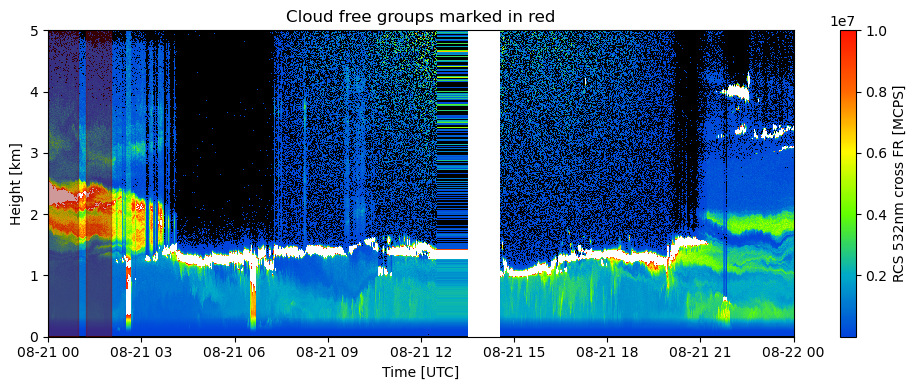

In [20]:
wv, t, tel = 532, 'cross', 'FR'

fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    np.squeeze(data_cube.retrievals_highres['RCS'][:, :, data_cube.gf(wv, t, tel)]).T,
    shading='nearest',
    cmap=labivew_cmap,
    vmin=5, vmax=1e7
)
for cldFreGrp in data_cube.clFreeGrps:
    ax.axvspan(
        data_cube.retrievals_highres["time64"][cldFreGrp[0]],
        data_cube.retrievals_highres["time64"][cldFreGrp[1]],
        color="darkred", alpha=0.4
    )

cbar = fig.colorbar(pcmesh)
cbar.set_label(f'RCS {wv}nm {t} {tel} [MCPS]')
ax.set_xlabel('Time [UTC]')
ax.set_ylabel('Height [km]')
ax.set_title('Cloud free groups marked in red')
ax.set_ylim(0, 5)
fig.tight_layout()

In [21]:
## Aggregate background, background corrected signal, and range corrected signal
data_cube.aggregate_profiles()

2026-08-13 17:24:20,729 - INFO - Aggregating variable: sigBGCor ...
2026-08-13 17:24:20,784 - INFO - Aggregating variable: BG ...
2026-08-13 17:24:20,785 - INFO - Aggregating variable: RCS ...
2026-08-13 17:24:20,833 - INFO - Aggregating variable: mShots ...
2026-08-13 17:24:20,835 - INFO - Aggregating variable: mask387Off ...
2026-08-13 17:24:20,836 - INFO - Aggregating variable: mask607Off ...
2026-08-13 17:24:20,838 - INFO - Aggregating variable: mask407Off ...


### Plot example: Aggregated profiles

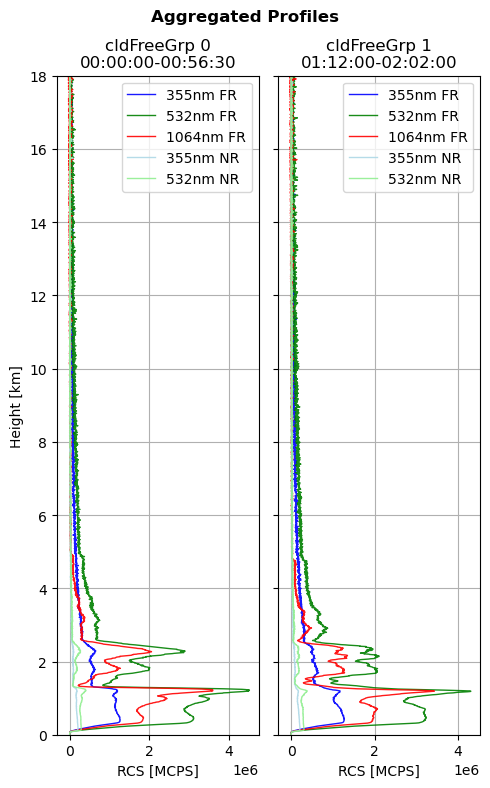

In [22]:
def getTimeInterval(timeArray:np.ndarray, interval:list|tuple):
    """Get time interval as string from time array and interval indices.

    Parameters
    ----------
    timeArray : ndarray
        Array of timestamps in ascending order.
    interval : list or tuple
        Indexes of the interval of ``timeArray`` to retrieve as a string.
    
    Returns
    -------
    out : str
        Time interval as a string.
    """
    start = np.datetime_as_string(timeArray[interval[0]]).split('T')[1].split('.')[0]
    stop = np.datetime_as_string(timeArray[interval[1]]).split('T')[1].split('.')[0]
    out = start + '-' + stop
    return out

fig, ax = plt.subplots(1, 2, figsize=(5, 8), sharey=True)
## Range Corrected Signal for the first cloud free region
ax[0].plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR')
ax[0].plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR')
ax[0].plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(1064, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR')
ax[0].plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm NR')
ax[0].plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm NR')
ax[0].grid()
ax[0].set_ylim(0, 18)
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Height [km]')
ax[0].set_xlabel('RCS [MCPS]')
ax[0].set_title(f'cldFreeGrp 0\n'+getTimeInterval(data_cube.retrievals_highres['time64'], data_cube.clFreeGrps[0]))

## Range Corrected Signal for the second cloud free region
ax[1].plot(np.squeeze(data_cube.retrievals_profile['RCS'][1, :, data_cube.gf(355, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR')
ax[1].plot(np.squeeze(data_cube.retrievals_profile['RCS'][1, :, data_cube.gf(532, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR')
ax[1].plot(np.squeeze(data_cube.retrievals_profile['RCS'][1, :, data_cube.gf(1064, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR')
ax[1].plot(np.squeeze(data_cube.retrievals_profile['RCS'][1, :, data_cube.gf(355, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm NR')
ax[1].plot(np.squeeze(data_cube.retrievals_profile['RCS'][1, :, data_cube.gf(532, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm NR')
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].legend(loc='upper right')
ax[1].set_xlabel('RCS [MCPS]')
ax[1].set_title(f'cldFreeGrp 1\n'+getTimeInterval(data_cube.retrievals_highres['time64'], data_cube.clFreeGrps[1]))
fig.suptitle("Aggregated Profiles", fontweight='bold')
fig.tight_layout()


## Molecular Profiles

The molecular profiles are calculated from cloudNet ECMWF model data. Gdas1 data is not supported in PicassoPy!

In [23]:
## QuickFix for loadMeteo bug:
METEO_DATA_DIR_PATH = "test_case_data"
data_cube.polly_config_dict['meteorDataSource'] = 'nc_cloudnet'
data_cube.polly_config_dict['meteo_folder'] = METEO_DATA_DIR_PATH
data_cube.polly_config_dict['meteo_file'] = r"[\\/]{0:%Y%m%d}_.*\.nc"

## Load meteorological data
data_cube.loadMeteo()

## Calculate molecular profiles
data_cube.calcMolecular()

2026-08-13 17:24:21,365 - INFO - Loading meteorological data ...
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\io\readMeteo.py:263: FutureWarning: In a future version, xarray will not decode the variable 'forecast_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.load_dataset(filename)
2026-08-13 17:24:21,493 - INFO - Performing model height correction.
2026-08-13 17:24:21,494 - INFO - Uncorrected model height[:,0]:
[10.466079  10.4652    10.460253  10.455192  10.449221  10.447984
 10.453651  10.460172  10.464973  10.472917  10.479133  10.48550

### Plot example: Molecular Backscatter and Extinction

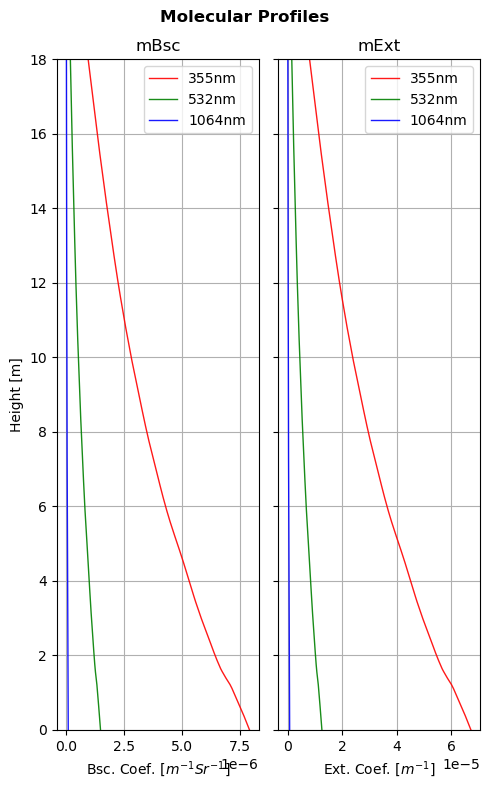

In [24]:
grpIdx = 0 # Cloud Free Group

fig, ax = plt.subplots(1, 2, figsize=(5, 8), sharey=True)
## Molecular Backscatter
ax[0].plot(data_cube.mol_profiles['mBsc_355'][grpIdx], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='355nm')
ax[0].plot(data_cube.mol_profiles['mBsc_532'][grpIdx], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm')
ax[0].plot(data_cube.mol_profiles['mBsc_1064'][grpIdx], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='1064nm')
ax[0].grid()
ax[0].set_ylim(0, 18)
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Height [m]')
ax[0].set_xlabel('Bsc. Coef. $[m^{-1}Sr^{-1}]$')
ax[0].set_title('mBsc')

## Molecular Extinction
ax[1].plot(data_cube.mol_profiles['mExt_355'][grpIdx], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='355nm')
ax[1].plot(data_cube.mol_profiles['mExt_532'][grpIdx], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm')
ax[1].plot(data_cube.mol_profiles['mExt_1064'][grpIdx], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='1064nm')
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].legend(loc='upper right')
ax[1].set_xlabel('Ext. Coef. $[m^{-1}]$')
ax[1].set_title('mExt')
fig.suptitle("Molecular Profiles", fontweight='bold')
fig.tight_layout()


## Rayleigh-Fit

- Douglas-Peucker algorithm is used to segment the signal into potential reference heights
- The reference height with the best fit to the molecular backscatter per channel is chosen
- Currently only done for FR-channels. NR reference heights are read from the config variables `refH_NR_{wavelength}`

In [25]:
## Rayleigh-fit procedure --> produces the reference heights
data_cube.rayleighFit()

2026-08-13 17:24:22,574 - INFO - Start Rayleigh Fit
2026-08-13 17:24:22,576 - WARNING - Potential for differences to matlab code due to numerical issues (subtraction of two small values)
2026-08-13 17:24:22,576 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-08-13 17:24:22,577 - WARNING - at 10km height this is a difference of about 4 indices
2026-08-13 17:24:22,578 - INFO - Cloud free segment 0, Time: 2024-08-21T00:00:00.000000 - 2024-08-21T00:56:30.000000.
2026-08-13 17:24:22,579 - INFO - Channel: 532 total FR.
2026-08-13 17:24:22,581 - WARNING - Warning: Odd smoothinglengs not allowd, will preform smoothing with length win - 1.
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\calibration\rayleighfit.py:574: RuntimeWarning: divide by zero encountered in divide
  std_aer_norm = sig_aer_norm / np.sqrt(pc + bg)
2026-08-13 17:24:22,615 - INFO - Channel: 355 total FR.
2026-08-13 17:24:22,617 - WARNING - Warning: Odd smoothingl

In [26]:
## Display reference heights for a given cloud free group
grpIdx = 0 # Cloud Free Group
print(f"""Reference heights in meters for cloud free period {grpIdx} {data_cube.retrievals_highres['time64'][data_cube.clFreeGrps[grpIdx]]}:
355 total FR:  {np.round(data_cube.retrievals_profile['refH'][grpIdx]["355_total_FR"]['refHeight'], 0)}
532 total FR:  {np.round(data_cube.retrievals_profile['refH'][grpIdx]["532_total_FR"]['refHeight'], 0)}
1064 total FR: {np.round(data_cube.retrievals_profile['refH'][grpIdx]["1064_total_FR"]['refHeight'], 0)}
355 total NR:  {np.round(data_cube.retrievals_profile['refH'][grpIdx]["355_total_NR"]['refHeight'], 0)}
532 total NR:  {np.round(data_cube.retrievals_profile['refH'][grpIdx]["532_total_NR"]['refHeight'], 0)}""")

Reference heights in meters for cloud free period 0 ['2024-08-21T00:00:00.000000' '2024-08-21T00:56:30.000000']:
355 total FR:  [ 6877. 12849.]
532 total FR:  [15768. 17935.]
1064 total FR: [13102. 13512.]
355 total NR:  [3005. 3995.]
532 total NR:  [3005. 3995.]


## GHK-Transmission Correction

In [27]:
## Molecular polarization calibration 
data_cube.polarizationCaliMol()

2026-08-13 17:24:22,960 - WARNING - 'flagMolDepolCali' set to False


In [28]:
## Apply GHK-transmission correction
data_cube.transCor()

2026-08-13 17:24:23,007 - INFO - GHK Transmission correction ...
2026-08-13 17:24:23,196 - INFO - Channel: 355 total FR | 355 cross FR
2026-08-13 17:24:23,351 - INFO - G [1.] [1.] H [0.02041] [-0.998] Eta 47.27529323156868 error [ 0.00016  0.01567 -0.00958] Window 1 
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\depolarization.py:195: RuntimeWarning: divide by zero encountered in divide
  sig_ratio = sigc / sigt
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\depolarization.py:195: RuntimeWarning: invalid value encountered in divide
  sig_ratio = sigc / sigt
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\depolarization.py:205: RuntimeWarning: invalid value encountered in divide
  vol_depol = (sig_ratio / eta * (Gt + Ht) - (Gr + Hr)) / ((Gr - Hr) - sig_ratio / eta * (Gt - Ht))
2026-08-13 17:24:23,818 - INFO - Channel: 532 total FR | 532 cross FR
2026-08-13 17:24:23,980 - INFO - G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.066747512729577 erro

In [29]:
## Aggregate GHK-transmission corrected profiles
data_cube.aggregate_profiles(var=['sigTCor', 'BGTCor'])

2026-08-13 17:24:25,164 - INFO - Aggregating variable: sigTCor ...
2026-08-13 17:24:25,218 - INFO - Aggregating variable: BGTCor ...


## Klett and Raman retrieval

Produces the following profiles per channel:
- Klett: Aerosol Backscatter and Extinction
- Raman: Aerosol Backscatter, Aerosol Extinction, and Lidar Ratio

If `nr=True`, perform the retrievals for FR and NR channels. Otherwise only FR.

In [30]:
## Klett retrieval for GHK-transmission corrected profiles
data_cube.retrievalKlett(nr=True)

2026-08-13 17:24:25,263 - INFO - Klett retrieval for FR & NR GHK-transmission corrected signal ...
2026-08-13 17:24:25,264 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-08-13 17:24:25,265 - WARNING - at 10km height this is a difference of about 4 indices
2026-08-13 17:24:25,265 - INFO - Cloud free segment 0, Time: 2024-08-21T00:00:00.000000 - 2024-08-21T00:56:30.000000.
2026-08-13 17:24:25,266 - INFO - Channel: 532, total, FR klett.
2026-08-13 17:24:25,316 - INFO - Channel: 355, total, FR klett.
2026-08-13 17:24:25,356 - INFO - Channel: 1064, total, FR klett.
2026-08-13 17:24:25,408 - INFO - Channel: 532, total, NR klett.
2026-08-13 17:24:25,451 - INFO - Channel: 355, total, NR klett.
2026-08-13 17:24:25,483 - INFO - Cloud free segment 1, Time: 2024-08-21T01:12:00.000000 - 2024-08-21T02:02:00.000000.
2026-08-13 17:24:25,484 - INFO - Channel: 532, total, FR klett.
2026-08-13 17:24:25,513 - INFO - Channel: 355, total, FR klett

### Plot example: Klett retrieved optical profiles

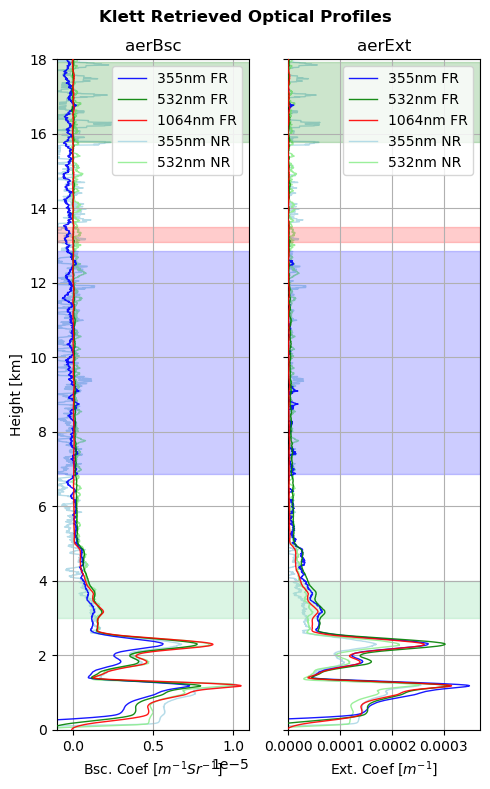

In [31]:
grpIdx = 0 # Cloud Free Group

fig, ax = plt.subplots(1, 2, figsize=(5, 8), sharey=True)
## Aerosol backscatter
ax[0].plot(data_cube.retrievals_profile['klett'][grpIdx]['355_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR', zorder=2)
ax[0].plot(data_cube.retrievals_profile['klett'][grpIdx]['532_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR', zorder=3)
ax[0].plot(data_cube.retrievals_profile['klett'][grpIdx]['1064_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR', zorder=4)
ax[0].plot(data_cube.retrievals_profile['klett'][grpIdx]['355_total_NR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm NR', zorder=0)
ax[0].plot(data_cube.retrievals_profile['klett'][grpIdx]['532_total_NR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm NR', zorder=1)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_NR']['refHeight'])/1000,  color='lightblue', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_NR']['refHeight'])/1000,  color='lightgreen', alpha=0.2)
ax[0].grid()
ax[0].set_ylim(0, 18)
ax[0].set_xlim(-1e-6, 11e-6)
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Height [km]')
ax[0].set_xlabel('Bsc. Coef $[m^{-1}Sr^{-1}]$')
ax[0].set_title('aerBsc')

## Aerosol Extinction
ax[1].plot(data_cube.retrievals_profile['klett'][grpIdx]['355_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR', zorder=2)
ax[1].plot(data_cube.retrievals_profile['klett'][grpIdx]['532_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR', zorder=3)
ax[1].plot(data_cube.retrievals_profile['klett'][grpIdx]['1064_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR', zorder=4)
ax[1].plot(data_cube.retrievals_profile['klett'][grpIdx]['355_total_NR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm NR', zorder=0)
ax[1].plot(data_cube.retrievals_profile['klett'][grpIdx]['532_total_NR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm NR', zorder=1)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_NR']['refHeight'])/1000,  color='lightblue', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_NR']['refHeight'])/1000,  color='lightgreen', alpha=0.2)
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].set_xlim(-1e-6, 3.7e-4)
ax[1].legend(loc='upper right')
ax[1].set_xlabel('Ext. Coef $[m^{-1}]$')
ax[1].set_title('aerExt')
fig.suptitle("Klett Retrieved Optical Profiles", fontweight='bold')
fig.tight_layout()

In [32]:
## Raman retrieval for GHK-transmission corrected profiles
data_cube.retrievalRaman(nr=True)

2026-08-13 17:24:26,156 - INFO - Raman retrieval for FR & NR GHK-transmission corrected signal ...
2026-08-13 17:24:26,157 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-08-13 17:24:26,158 - WARNING - at 10km height this is a difference of about 4 indices
2026-08-13 17:24:26,159 - INFO - Cloud free segment 0, Time: 2024-08-21T00:00:00.000000 - 2024-08-21T00:56:30.000000.
2026-08-13 17:24:26,160 - INFO - Channels: 355, total, FR | 387, total, FR raman.
c:\Users\buholdt\AppData\Local\miniconda3\envs\PicassoPy\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
2026-08-13 17:24:26,398 - INFO - Filling aerExt below overlap with 0.00010661377416860892 for calculating the backscatter
2026-08-13 17:24:26,883 - INFO - Channels: 532, total, FR | 607, total, FR raman.
2026-08-13 17:24:27,013 - INFO - Filling aerExt below

### Plot example: Raman retrieved optical profiles

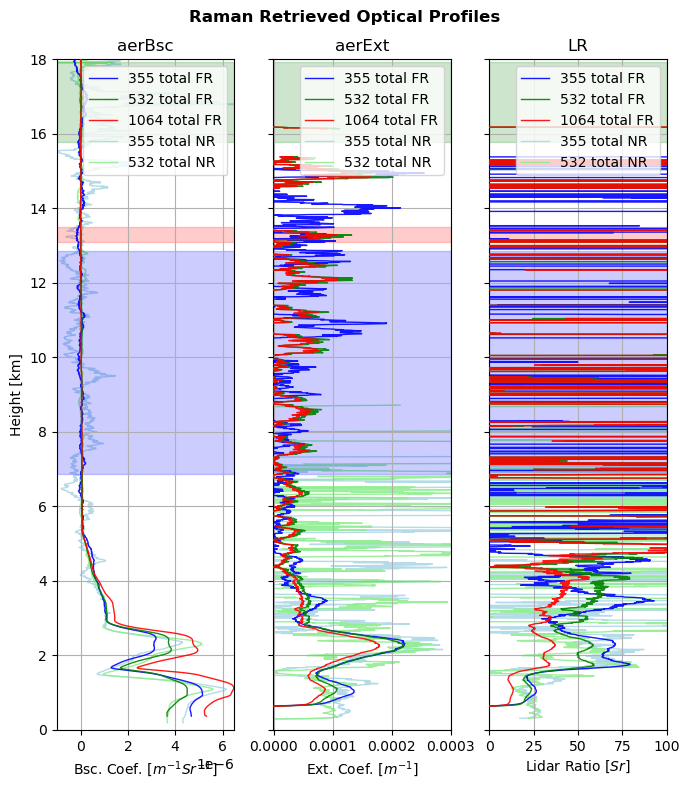

In [33]:
grpIdx = 0 # Cloud Free Group

fig, ax = plt.subplots(1, 3, figsize=(7, 8), sharey=True)
## Aerosol backscatter
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355 total FR', zorder=2)
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532 total FR', zorder=3)
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['1064_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064 total FR', zorder=4)
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_NR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355 total NR', zorder=0)
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_NR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532 total NR', zorder=1)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[0].grid()
ax[0].set_ylim(0, 18)
ax[0].set_xlim(-1e-6, 6.5e-6)
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Height [km]')
ax[0].set_xlabel('Bsc. Coef. $[m^{-1}Sr^{-1}]$')
ax[0].set_title('aerBsc')

## Aerosol Extinction
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355 total FR', zorder=2)
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532 total FR', zorder=3)
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['1064_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064 total FR', zorder=4)
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_NR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355 total NR', zorder=0)
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_NR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532 total NR', zorder=1)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].set_xlim(-1e-6, 3e-4)
ax[1].legend(loc='upper right')
ax[1].set_xlabel('Ext. Coef. $[m^{-1}]$')
ax[1].set_title('aerExt')

## Lidar Ratio
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355 total FR', zorder=2)
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532 total FR', zorder=3)
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['1064_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064 total FR', zorder=4)
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_NR']['LR'], data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355 total NR', zorder=0)
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_NR']['LR'], data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532 total NR', zorder=1)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[2].grid()
ax[2].set_ylim(0, 18)
ax[2].set_xlim(0, 100)
ax[2].legend(loc='upper right')
ax[2].set_xlabel('Lidar Ratio $[Sr]$')
ax[2].set_title('LR')
fig.suptitle("Raman Retrieved Optical Profiles", fontweight='bold')
fig.tight_layout()

## Overlap Correction

Two methods are available for calculating the Overlap Function:

1. FRNR method
2. Raman method

And four methods (currently only 3 implemented) are available for applying the Overlap Correction:

0. no overlap correction
1. overlap correction with using the default overlap function (read function from file)
2. overlap correction with using the calculated overlap function
3. overlap correction with gluing near-range and far-range signal -> Not implemented yet!


In [34]:
## Calculate overlap function
data_cube.overlapCalc()

## Fix spike in lower bins
data_cube.overlapFixLowestBins()

## Apply overlap correction
data_cube.overlapCor()

2026-08-13 17:24:32,750 - INFO - calculating overlap functions ...
2026-08-13 17:24:32,751 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-08-13 17:24:32,752 - WARNING - at 10km height this is a difference of about 4 indices
2026-08-13 17:24:32,752 - INFO - Starting Overlap retrieval
2026-08-13 17:24:32,753 - INFO - Cloud free segment: 0. Time: 2024-08-21T00:00:00.000000 - 2024-08-21T00:56:30.000000.
2026-08-13 17:24:32,753 - INFO - Channels: 355 total FR | 355 total NR.
2026-08-13 17:24:33,054 - INFO - Channels: 387 total FR | 387 total NR.
2026-08-13 17:24:33,336 - INFO - Channels: 532 total FR | 532 total NR.
2026-08-13 17:24:33,614 - INFO - Channels: 607 total FR | 607 total NR.
2026-08-13 17:24:33,895 - INFO - Cloud free segment: 1. Time: 2024-08-21T01:12:00.000000 - 2024-08-21T02:02:00.000000.
2026-08-13 17:24:33,896 - INFO - Channels: 355 total FR | 355 total NR.
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\misc\

In [35]:
## Aggregate overlap corrected profiles
data_cube.aggregate_profiles(var=['sigOLCor', 'BGOLCor'])

2026-08-13 17:24:40,945 - INFO - Aggregating variable: sigOLCor ...
2026-08-13 17:24:40,985 - INFO - Aggregating variable: BGOLCor ...


In [36]:
## Klett retrieval for overlap corrected profiles
data_cube.retrievalKlett(oc=True)

## Raman retrieval for overlap corrected profiles
data_cube.retrievalRaman(oc=True)

2026-08-13 17:24:41,028 - INFO - Klett retrieval for FR None overlap corrected signal ...
2026-08-13 17:24:41,029 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-08-13 17:24:41,030 - WARNING - at 10km height this is a difference of about 4 indices
2026-08-13 17:24:41,031 - INFO - Cloud free segment 0, Time: 2024-08-21T00:00:00.000000 - 2024-08-21T00:56:30.000000.
2026-08-13 17:24:41,032 - INFO - Channel: 532, total, FR klett.
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\klettfernald.py:276: RuntimeWarning: invalid value encountered in scalar divide
  denominator1 = RCS[iAlt + 1] / (aerBsc[iAlt + 1] + molBsc[iAlt + 1])
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\klettfernald.py:310: RuntimeWarning: divide by zero encountered in divide
  aerRelBRStd = np.abs((1 + noise / signal) / (1 + aerBsc + molBsc / 1e3) - 1)
2026-08-13 17:24:41,063 - INFO - Channel: 355, total, FR klett.
2026-08-13 17:24

### Plot example: Overlap Corrected Raman retrieved optical profiles

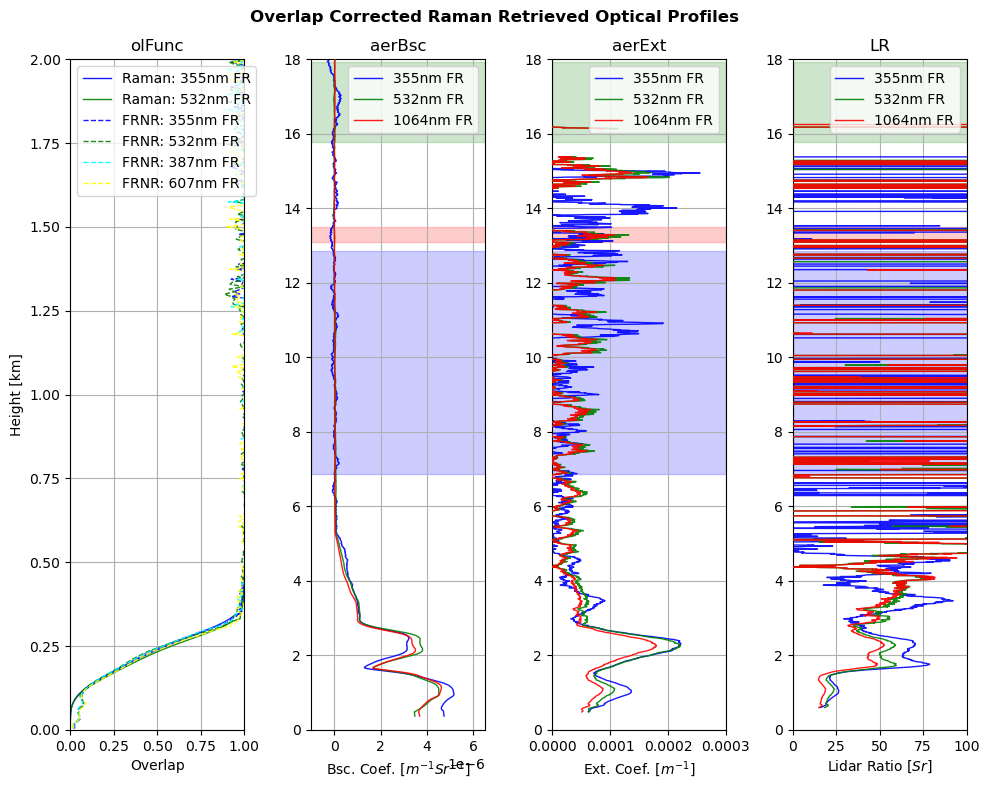

In [37]:
grpIdx = 0 # Cloud Free Group

fig, ax = plt.subplots(1, 4, figsize=(10, 8))
## Overlap Function
ax[0].plot(data_cube.retrievals_profile['overlap']['raman'][grpIdx]['355_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, linestyle='solid', label='Raman: 355nm FR')
ax[0].plot(data_cube.retrievals_profile['overlap']['raman'][grpIdx]['532_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, linestyle='solid', label='Raman: 532nm FR')
ax[0].plot(data_cube.retrievals_profile['overlap']['frnr'][grpIdx]['355_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, linestyle='dashed', label='FRNR: 355nm FR')
ax[0].plot(data_cube.retrievals_profile['overlap']['frnr'][grpIdx]['532_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, linestyle='dashed', label='FRNR: 532nm FR')
ax[0].plot(data_cube.retrievals_profile['overlap']['frnr'][grpIdx]['387_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='cyan', alpha=0.9, linewidth=1, linestyle='dashed', label='FRNR: 387nm FR')
ax[0].plot(data_cube.retrievals_profile['overlap']['frnr'][grpIdx]['607_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='yellow', alpha=0.9, linewidth=1, linestyle='dashed', label='FRNR: 607nm FR')
ax[0].grid()
ax[0].set_ylim(0, 2)
ax[0].set_xlim(0, 1)
ax[0].legend(loc='upper left')
ax[0].set_ylabel('Height [km]')
ax[0].set_xlabel('Overlap')
ax[0].set_title('olFunc')

## Aerosol backscatter
ax[1].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['355_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR', zorder=2)
ax[1].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['532_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR', zorder=3)
ax[1].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['1064_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR', zorder=4)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].set_xlim(-1e-6, 6.5e-6)
ax[1].legend(loc='upper right')
ax[1].set_xlabel('Bsc. Coef. $[m^{-1}Sr^{-1}]$')
ax[1].set_title('aerBsc')

## Aerosol Extinction
ax[2].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['355_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR', zorder=2)
ax[2].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['532_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR', zorder=3)
ax[2].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['1064_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR', zorder=4)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[2].grid()
ax[2].set_ylim(0, 18)
ax[2].set_xlim(-1e-6, 3e-4)
ax[2].legend(loc='upper right')
ax[2].set_xlabel('Ext. Coef. $[m^{-1}]$')
ax[2].set_title('aerExt')

## Lidar Ratio
ax[3].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['355_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR', zorder=2)
ax[3].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['532_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR', zorder=3)
ax[3].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['1064_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR', zorder=4)
ax[3].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[3].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[3].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[3].grid()
ax[3].set_ylim(0, 18)
ax[3].set_xlim(0, 100)
ax[3].legend(loc='upper right')
ax[3].set_xlabel('Lidar Ratio $[Sr]$')
ax[3].set_title('LR')
fig.suptitle("Overlap Corrected Raman Retrieved Optical Profiles", fontweight='bold')
fig.tight_layout()

## Depol and Ångström Profiles

Retrieval of Volume and Particle depolarization as well as Ångström 355/532 backscatter 532/1064 backscatter, adn 355/532 Extinction

In [38]:
## Volume and particle depolarization
data_cube.calcDepol()

2026-08-13 17:24:46,031 - INFO - Calculate volume and particle depolarization ratios for product klett ...
2026-08-13 17:24:46,032 - INFO - voldepol at channel 532 cldFree 0 (np.int64(0), np.int64(114))
2026-08-13 17:24:46,033 - INFO - G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.066747512729577 error [ 0.00027  0.02024 -0.00463] Window 25 
2026-08-13 17:24:46,035 - INFO - G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.066747512729577 error [ 0.00027  0.02024 -0.00463] Window 1 
2026-08-13 17:24:46,036 - INFO - voldepol at channel 355 cldFree 0 (np.int64(0), np.int64(114))
2026-08-13 17:24:46,037 - INFO - G [1.] [1.] H [0.02041] [-0.998] Eta 47.27529323156868 error [ 0.00016  0.01567 -0.00958] Window 25 
2026-08-13 17:24:46,039 - INFO - G [1.] [1.] H [0.02041] [-0.998] Eta 47.27529323156868 error [ 0.00016  0.01567 -0.00958] Window 1 
2026-08-13 17:24:46,041 - INFO - voldepol at channel 1064 cldFree 0 (np.int64(0), np.int64(114))
2026-08-13 17:24:46,042 - INFO - G [1.] [1.] H [-0.02439] [-0.99

In [39]:
## Ångström ratios
data_cube.Angstroem()

2026-08-13 17:24:46,316 - INFO - Calculate Angstrom exponents for product klett ...
2026-08-13 17:24:46,317 - INFO - Channels: 355_total_FR, 532_total_FR. Product: Bsc.
2026-08-13 17:24:46,320 - INFO - Channels: 355_total_NR, 532_total_NR. Product: Bsc.
2026-08-13 17:24:46,321 - INFO - Channels: 532_total_FR, 1064_total_FR. Product: Bsc.
2026-08-13 17:24:46,323 - INFO - Channels: 355_total_FR, 532_total_FR. Product: Ext.
2026-08-13 17:24:46,324 - INFO - Channels: 355_total_NR, 532_total_NR. Product: Ext.
2026-08-13 17:24:46,326 - INFO - Channels: 355_total_FR, 532_total_FR. Product: Bsc.
2026-08-13 17:24:46,328 - INFO - Channels: 355_total_NR, 532_total_NR. Product: Bsc.
2026-08-13 17:24:46,329 - INFO - Channels: 532_total_FR, 1064_total_FR. Product: Bsc.
2026-08-13 17:24:46,331 - INFO - Channels: 355_total_FR, 532_total_FR. Product: Ext.
2026-08-13 17:24:46,332 - INFO - Channels: 355_total_NR, 532_total_NR. Product: Ext.
2026-08-13 17:24:46,334 - INFO - Calculate Angstrom exponents fo

### Plot example: Depol and Ångström ratio profiles

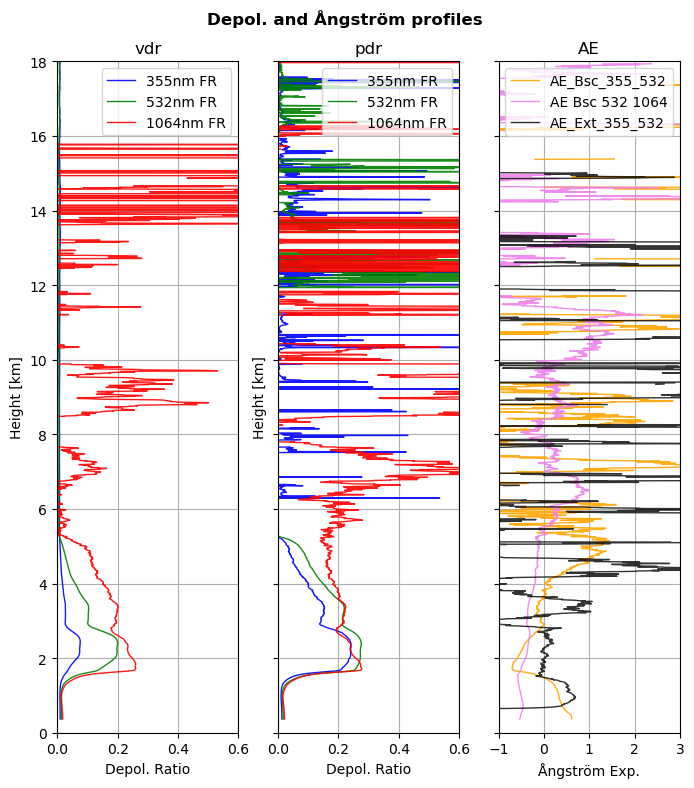

In [40]:
grpIdx = 0 # Cloud Free Group

fig, ax = plt.subplots(1, 3, figsize=(7, 8), sharey=True)
## Volume Depolarization Ratio
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['vdr'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR')
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['vdr'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR')
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['1064_total_FR']['vdr'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR')
ax[0].grid()
ax[0].set_ylim(0, 18)
ax[0].set_xlim(-1e-3, 6e-1)
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Height [km]')
ax[0].set_xlabel('Depol. Ratio')
ax[0].set_title('vdr')

## Particle Depolarization Ratio
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['pdr'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR')
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['pdr'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR')
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['1064_total_FR']['pdr'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR')
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].set_xlim(-1e-3, 6e-1)
ax[1].legend(loc='upper right')
ax[1].set_ylabel('Height [km]')
ax[1].set_xlabel('Depol. Ratio')
ax[1].set_title('pdr')

## Ångström ratios at cloud free period 0
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['AE_Bsc_355_532'], data_cube.retrievals_highres['height']/1000, color='orange', alpha=0.9, linewidth=1, label='AE_Bsc_355_532')
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['AE_Bsc_532_1064'], data_cube.retrievals_highres['height']/1000, color='violet', alpha=0.9, linewidth=1, label='AE Bsc 532 1064')
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['AE_Ext_355_532'], data_cube.retrievals_highres['height']/1000, color='black', alpha=0.8, linewidth=1, label='AE_Ext_355_532')
ax[2].grid()
ax[2].set_ylim(0, 18)
ax[2].set_xlim(-1, 3)
ax[2].legend(loc='upper right')
ax[2].set_xlabel('Ångström Exp.')
ax[2].set_title('AE')
fig.suptitle("Depol. and Ångström profiles", fontweight='bold')
fig.tight_layout()


## Lidar Calibration

- Lidar calibration constants (LC) are retieved for each channel at each cloud free period for both Klett and Raman retieved profiles
- All retrieved LCs are stored in the database
- If no LCs can be retrieved for a given channel, the LCs in the time range [24h before the measurment, 24h after the measurement] for the given channel included in the database will be used
- The optimal LC, ie. the one with the lowest standard deviation per channel is used for the processing.
- The following priority order is used when choosing the optimal LC
    1. Raman retrieved LC from data
    2. Klett retrieved LC from data
    3. Raman retrieved LC from database
    4. Klett retrieved LC from database

In [41]:
## Lidar calibration for both Klett and Raman retrieval
data_cube.LidarCalibration()

2026-08-13 17:24:46,979 - INFO - Calculating lidar calibration constants ...
2026-08-13 17:24:46,980 - INFO - LC retrieval: klett method
2026-08-13 17:24:46,988 - INFO - Using Retrieved Exticntion
2026-08-13 17:24:47,048 - INFO - cldFreGrp 0, Channel 532 total FR, LC_stable 110480476774235.88, LCStd 0.0022347503798313562
2026-08-13 17:24:47,055 - INFO - Using Retrieved Exticntion
2026-08-13 17:24:47,115 - INFO - cldFreGrp 0, Channel 355 total FR, LC_stable 25663860675124.36, LCStd 0.0016978384613928579
2026-08-13 17:24:47,121 - INFO - Using Retrieved Exticntion
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\misc\helper.py:1256: RuntimeWarning: Mean of empty slice
  thisMean = np.nanmean(window)
2026-08-13 17:24:47,180 - INFO - cldFreGrp 0, Channel 1064 total FR, LC_stable 70615096577805.12, LCStd 0.003027279079923954
2026-08-13 17:24:47,186 - INFO - Using Retrieved Exticntion
2026-08-13 17:24:47,246 - INFO - cldFreGrp 0, Channel 532 total NR, LC_stable 7336742488577.648, LCStd 0.0

In [42]:
## Display Lidar calibration constants per channel
data_cube.LCused

{'532_total_FR': np.float64(113784215905298.44),
 '355_total_FR': np.float64(17022098372209.125),
 '1064_total_FR': np.float64(50812275764219.61),
 '532_total_NR': np.float64(8843202624859.408),
 '355_total_NR': np.float64(2755558268816.5083),
 '387_total_FR': np.float64(48925494588027.48),
 '607_total_FR': np.float64(290870505264845.75),
 '607_total_NR': np.float64(13494237887722.975),
 '387_total_NR': np.float64(4006008627669.4106)}

In [43]:
## Store calibration constants in database
data_cube.write_2_sql_db(db_path=str(DATABASE_PATH), parameter='LC', method='raman')
data_cube.write_2_sql_db(db_path=str(DATABASE_PATH), parameter='LC', method='klett')
data_cube.write_2_sql_db(db_path=str(DATABASE_PATH), parameter='DC')

2026-08-13 17:24:48,974 - INFO - writing to sqlite-db: PicassoPyDatabase.db
2026-08-13 17:24:48,975 - INFO - writing LC to table: lidar_calibration_constant
2026-08-13 17:24:48,989 - INFO - 18 rows inserted into 'lidar_calibration_constant'.
2026-08-13 17:24:48,990 - INFO - writing to sqlite-db: PicassoPyDatabase.db
2026-08-13 17:24:48,992 - INFO - writing LC to table: lidar_calibration_constant
2026-08-13 17:24:48,998 - INFO - 10 rows inserted into 'lidar_calibration_constant'.
2026-08-13 17:24:48,999 - INFO - writing to sqlite-db: PicassoPyDatabase.db
2026-08-13 17:24:49,000 - INFO - writing DC to table: depol_calibration_constant
2026-08-13 17:24:49,005 - INFO - 5 rows inserted into 'depol_calibration_constant'.


dict_keys(['klett', 'raman', 'klett_db', 'raman_db'])
dict_keys(['klett', 'raman', 'klett_db', 'raman_db'])
dict_keys(['klett', 'raman', 'klett_db', 'raman_db'])


In [56]:
## Save retrieved optical profiles
write_profile2nc_file(data_cube=data_cube, prod_ls=["profiles", "NR_profiles", "OC_profiles"])

2026-08-13 17:29:06,889 - INFO - saving product: profiles
2026-08-13 17:29:07,098 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0000_0056_profiles.nc
2026-08-13 17:29:07,510 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0112_0202_profiles.nc
2026-08-13 17:29:07,661 - INFO - saving product: NR_profiles
2026-08-13 17:29:07,773 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0000_0056_NR_profiles.nc
2026-08-13 17:29:07,909 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0112_0202_NR_profiles.nc
2026-08-13 17:29:07,947 - INFO - saving product: OC_profiles
2026-08-13 17:29:08,048 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0000_0056_OC_profiles.nc
2026-08-13 17:29:08,256 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0112_0202_OC_profiles.nc


## High Resoulution Retrievals

The following high resolution (30s) time-height data are retrieved: 

- Attenuated backscatter
- Volume depolarization
- Molecular backscatter and extinction
- Quality mask
- QuasiV1 and QuasiV2 retrievals
- Target categorization V1 and V2

In [45]:
## Highres attenuated backscatter and volume depolarization
data_cube.attBsc_volDepol()

## Highres molecular signal
data_cube.molecularHighres()

2026-08-13 17:24:50,343 - INFO - 2D attenuated backscatter retrieval ...
2026-08-13 17:24:51,319 - WARNING - Exprimental, attenuated backscatter solution for 387_total_NR
2026-08-13 17:24:51,665 - INFO - Channel: 355 total FR | 355 cross FR
2026-08-13 17:24:51,887 - INFO - G [1.] [1.] H [0.02041] [-0.998] Eta 47.27529323156868 error [ 0.00016  0.01567 -0.00958] Window 1 
2026-08-13 17:24:52,627 - INFO - Channel: 532 total FR | 532 cross FR
2026-08-13 17:24:52,887 - INFO - G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.066747512729577 error [ 0.00027  0.02024 -0.00463] Window 1 
2026-08-13 17:24:53,656 - INFO - Channel: 1064 total FR | 1064 cross FR
2026-08-13 17:24:53,887 - INFO - G [1.] [1.] H [-0.02439] [-0.996] Eta 0.14061415579754508 error [ 0.00133  0.02379 -0.01205] Window 1 
2026-08-13 17:24:54,910 - INFO - 2D volume depolarization ratio retrieval ...
2026-08-13 17:24:55,082 - INFO - G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.066747512729577 error [ 0.00027  0.02024 -0.00463] Window 1

### Plot Example: Highres Attenuated Backscatter & Volume Depolarization

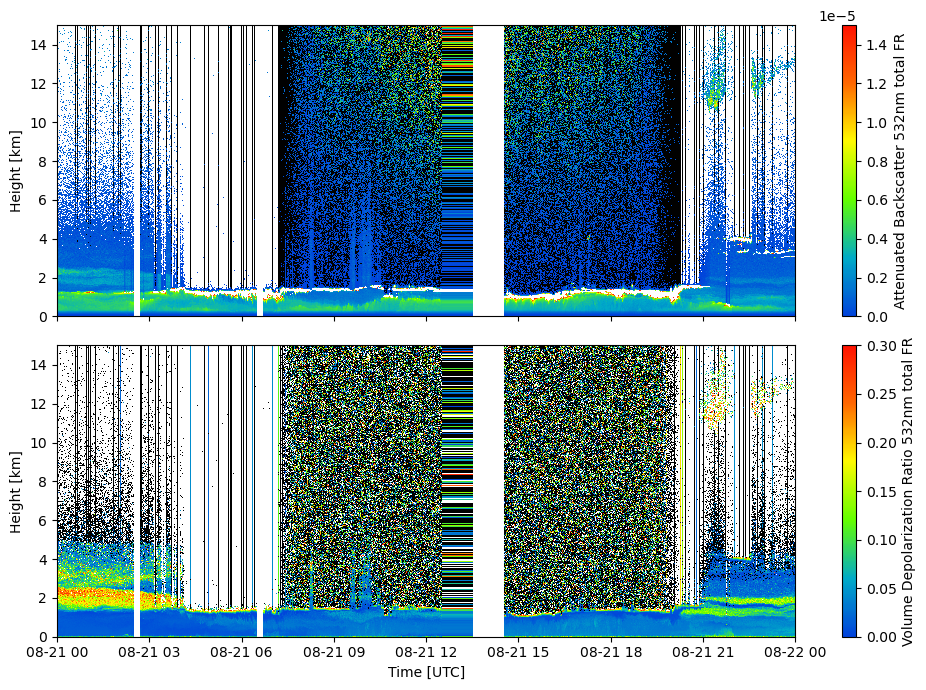

In [46]:
wv, t, tel = 532, 'total', 'FR'

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
pcmeshATB = ax[0].pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    data_cube.retrievals_highres[f"attBsc_{wv}_{t}_{tel}"].T,
    shading='nearest',
    cmap=labivew_cmap,
    vmin=0, vmax=1.5e-5
)
cbar = fig.colorbar(pcmeshATB)
cbar.set_label(f'Attenuated Backscatter {wv}nm {t} {tel}')
ax[0].set_ylabel('Height [km]')
ax[0].set_ylim(0, 15)

pcmeshVD = ax[1].pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    data_cube.retrievals_highres[f"voldepol_{wv}_{t}_{tel}"].T,
    shading='nearest',
    cmap=labivew_cmap,
    vmin=0, vmax=0.3
)
cbar = fig.colorbar(pcmeshVD)
cbar.set_label(f"Volume Depolarization Ratio {wv}nm {t} {tel}")
ax[1].set_xlabel('Time [UTC]')
ax[1].set_ylabel('Height [km]')
ax[1].set_ylim(0, 15)
fig.tight_layout()

In [47]:
## Quality mask of signal
data_cube.estQualityMask()

2026-08-13 17:25:13,955 - INFO - Estimate quality masks ...
2026-08-13 17:25:13,956 - INFO - Calculating SNR from smoothed signal to improve data quality...
2026-08-13 17:25:14,745 - INFO - Vectorized group 0, Nr = 3, Nc = 10 ...
2026-08-13 17:25:33,735 - INFO - Using improved SNR in quality mask estimation.


### Plot example: Quality Mask

C:\Users\buholdt\AppData\Local\Temp\ipykernel_30780\878051702.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Set3', 6),


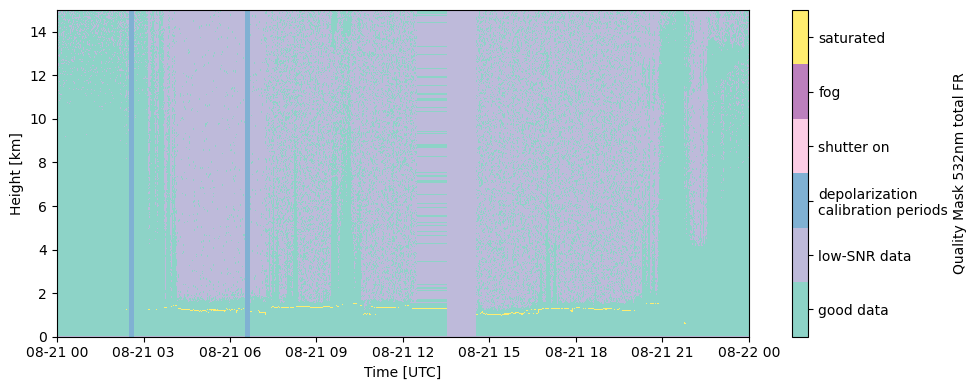

In [48]:
wv, t, tel = 532, 'total', 'FR'

fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'], 
    np.array(data_cube.retrievals_highres['height'])/1000, 
    np.squeeze(data_cube.retrievals_highres['quality_mask'][:, :, data_cube.gf(wv, t, tel)]).T, 
    shading='nearest',
    cmap=plt.cm.get_cmap('Set3', 6),
    vmin=-0.5, vmax=5.5
)

cats = {
    0: "good data",
    1: "low-SNR data",
    2: "depolarization\ncalibration periods",
    3: "shutter on",
    4: "fog",
    5: "saturated"
}
formatter = plt.FuncFormatter(lambda val, loc:cats[val])
cbar = fig.colorbar(pcmesh, ticks=np.arange(0, 6), format=formatter)
cbar.set_label(f"Quality Mask {wv}nm {t} {tel}")
ax.set_ylim(0, 15)
ax.set_ylabel('Height [km]')
ax.set_xlabel("Time [UTC]")
fig.tight_layout()

In [49]:
## QuasiV1 retrievals and Target categorization
data_cube.quasiV1()

2026-08-13 17:25:41,574 - INFO - Calculating Quasi V1 particle backscatter coefficient
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV1.py:134: RuntimeWarning: divide by zero encountered in divide
  quasi_par_bsc = att_beta / (mol_att * quasi_par_att)**2 - molBsc
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV1.py:134: RuntimeWarning: overflow encountered in divide
  quasi_par_bsc = att_beta / (mol_att * quasi_par_att)**2 - molBsc
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV1.py:136: RuntimeWarning: overflow encountered in multiply
  quasi_par_ext = quasi_par_bsc * LRaer
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV1.py:133: RuntimeWarning: overflow encountered in multiply
  quasi_par_att = np.exp(-np.nancumsum(quasi_par_ext * diff_height, axis=1))
c:\Users\buholdt\AppData\Local\miniconda3\envs\PicassoPy\Lib\site-packages\numpy\_core\fromnumeric.py:57: RuntimeWarning: overflow encountered in ac

### Plot example: Quasi Attenuated Backscatter & Particle Depolarization Version 1

c:\Users\buholdt\AppData\Local\miniconda3\envs\PicassoPy\Lib\site-packages\matplotlib\colors.py:2295: RuntimeWarning: overflow encountered in divide
  resdat /= (vmax - vmin)
c:\Users\buholdt\AppData\Local\miniconda3\envs\PicassoPy\Lib\site-packages\matplotlib\colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


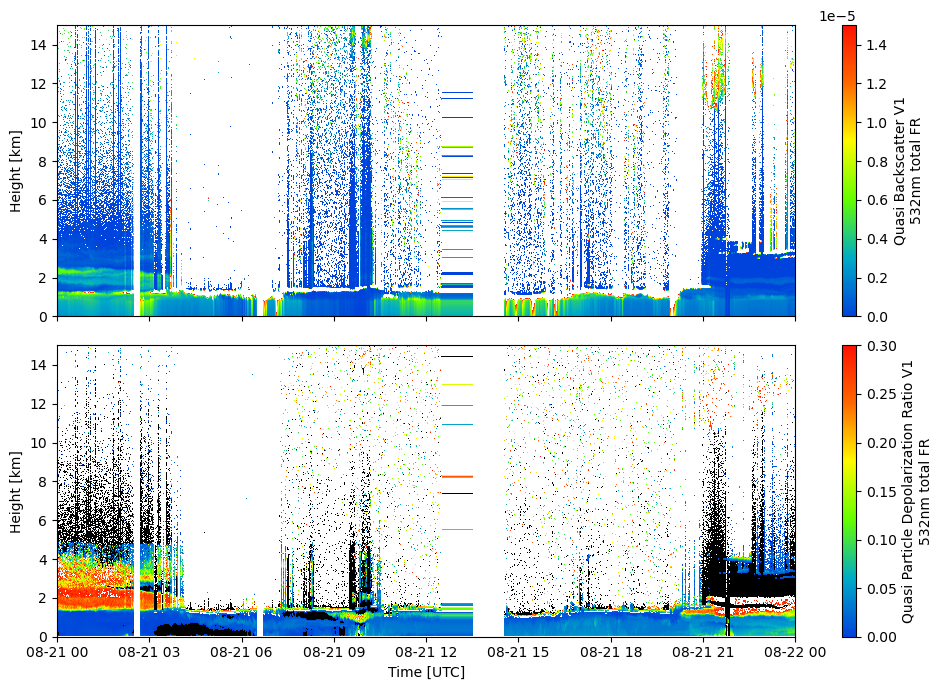

In [50]:
wv, t, tel = 532, 'total', 'FR'

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
pcmeshQBV1 = ax[0].pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    data_cube.retrievals_highres[f"quasiBscV1_{wv}_{t}_{tel}"].T,
    shading='nearest',
    cmap=labivew_cmap,
    vmin=0, vmax=1.5e-5
)
cbar = fig.colorbar(pcmeshQBV1)
cbar.set_label(f'Quasi Backscatter V1\n{wv}nm {t} {tel}')
ax[0].set_ylabel('Height [km]')
ax[0].set_ylim(0, 15)

pcmeshQPDV1 = ax[1].pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    data_cube.retrievals_highres[f"quasiPdrV1_{wv}_{t}_{tel}"].T,
    shading='nearest',
    cmap=labivew_cmap,
    vmin=0, vmax=0.3
)
cbar = fig.colorbar(pcmeshQPDV1)
cbar.set_label(f"Quasi Particle Depolarization Ratio V1\n{wv}nm {t} {tel}")
ax[1].set_xlabel('Time [UTC]')
ax[1].set_ylabel('Height [km]')
ax[1].set_ylim(0, 15)
fig.tight_layout()

### Plot example: Target Categorization Version 1

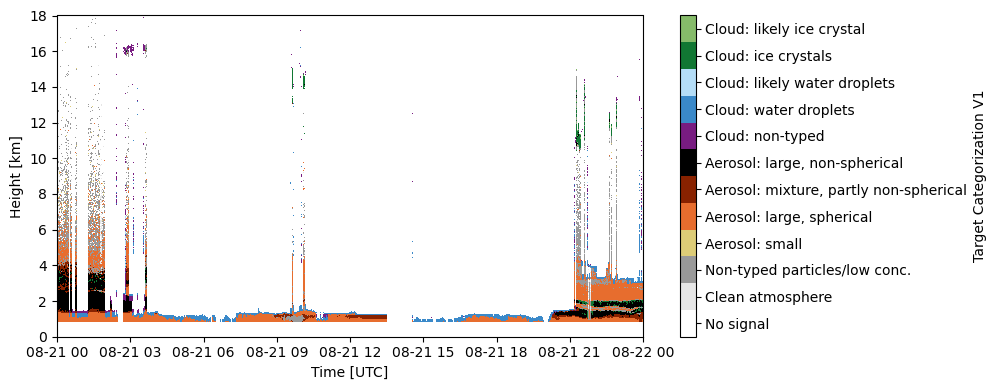

In [51]:
fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    np.array(data_cube.retrievals_highres['height'])/1000, 
    data_cube.retrievals_highres['tcMaskV1'].T,
    shading='nearest',
    cmap=tc_cmap,
    vmin=-0.5, vmax=11.5
)

cats = {
    0: 'No signal',
    1: 'Clean atmosphere',
    2: 'Non-typed particles/low conc.',
    3: 'Aerosol: small',
    4: 'Aerosol: large, spherical',
    5: 'Aerosol: mixture, partly non-spherical',
    6: 'Aerosol: large, non-spherical',
    7: 'Cloud: non-typed',
    8: 'Cloud: water droplets',
    9: 'Cloud: likely water droplets',
    10: 'Cloud: ice crystals',
    11: 'Cloud: likely ice crystal',
}
formatter = plt.FuncFormatter(lambda val, loc:cats[val])
cbar = fig.colorbar(pcmesh, ticks=np.arange(0, 12), format=formatter)
cbar.set_label('Target Categorization V1')
ax.set_ylim(0, 18)
ax.set_ylabel('Height [km]')
ax.set_xlabel('Time [UTC]')
fig.tight_layout()

In [52]:
## QuasiV2 retrievals and Target categorization
data_cube.quasiV2()

2026-08-13 17:26:34,170 - INFO - Calculating Quasi V2 particle backscatter coefficient
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV2.py:170: RuntimeWarning: divide by zero encountered in divide
  quasi_par_bsc = (att_beta_el / att_beta_ra) * quasi_par_att - molBscEl
c:\Users\buholdt\AppData\Local\miniconda3\envs\PicassoPy\Lib\site-packages\numpy\_core\fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV2.py:169: RuntimeWarning: overflow encountered in exp
  quasi_par_att = np.exp((1 - (wv / wv_r)**AE) * OD_par + (OD_mol - OD_mol_r)) * molBscEl
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV2.py:170: RuntimeWarning: invalid value encountered in multiply
  quasi_par_bsc = (att_beta_el / att_beta_ra) * quasi_par_att - molBscEl
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV2.py:167: RuntimeWarning: ov

### Plot example: Quasi Attenuated Backscatter & Volume Depolarization Version 1

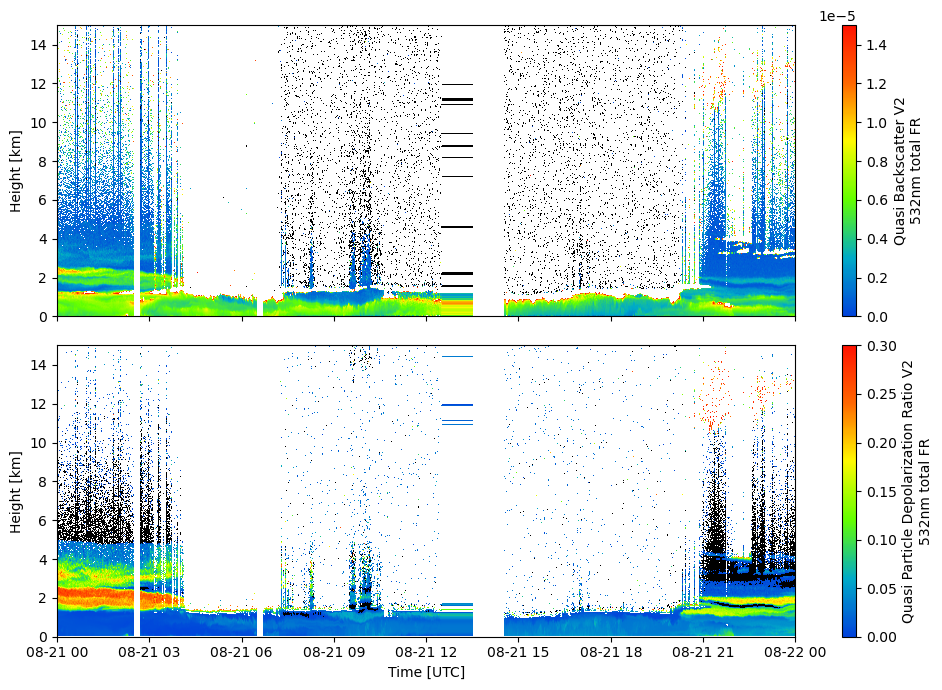

In [53]:
wv, t, tel = 532, 'total', 'FR'

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
pcmeshQB = ax[0].pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    data_cube.retrievals_highres[f"quasiBscV2_{wv}_{t}_{tel}"].T,
    shading='nearest',
    cmap=labivew_cmap,
    vmin=0, vmax=1.5e-5
)
cbar = fig.colorbar(pcmeshQB)
cbar.set_label(f'Quasi Backscatter V2\n{wv}nm {t} {tel}')
ax[0].set_ylabel('Height [km]')
ax[0].set_ylim(0, 15)

pcmeshQPD = ax[1].pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    data_cube.retrievals_highres[f"quasiPdrV2_{wv}_{t}_{tel}"].T,
    shading='nearest',
    cmap=labivew_cmap,
    vmin=0, vmax=0.3
)
cbar = fig.colorbar(pcmeshQPD)
cbar.set_label(f"Quasi Particle Depolarization Ratio V2\n{wv}nm {t} {tel}")
ax[1].set_xlabel('Time [UTC]')
ax[1].set_ylabel('Height [km]')
ax[1].set_ylim(0, 15)
fig.tight_layout()

### Plot example: Target Categorization Version 2

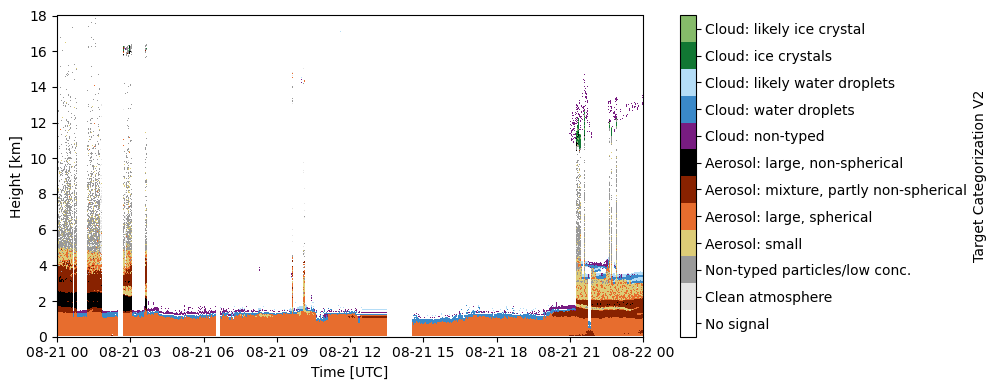

In [54]:
fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    np.array(data_cube.retrievals_highres['height'])/1000, 
    data_cube.retrievals_highres['tcMaskV2'].T,
    shading='nearest',
    cmap=tc_cmap,
    vmin=-0.5, vmax=11.5,
)

cats = {
    0: 'No signal',
    1: 'Clean atmosphere',
    2: 'Non-typed particles/low conc.',
    3: 'Aerosol: small',
    4: 'Aerosol: large, spherical',
    5: 'Aerosol: mixture, partly non-spherical',
    6: 'Aerosol: large, non-spherical',
    7: 'Cloud: non-typed',
    8: 'Cloud: water droplets',
    9: 'Cloud: likely water droplets',
    10: 'Cloud: ice crystals',
    11: 'Cloud: likely ice crystal',
}
formatter = plt.FuncFormatter(lambda val, loc:cats[val])
cbar = fig.colorbar(pcmesh, ticks=np.arange(0, 12), format=formatter)
cbar.set_label('Target Categorization V2')
ax.set_ylim(0, 18)
ax.set_ylabel('Height [km]')
ax.set_xlabel('Time [UTC]')
fig.tight_layout()

In [55]:
## Save highres retrievals
write2nc_file(data_cube=data_cube, prod_ls=["att_bsc", "NR_att_bsc", "OC_att_bsc", "vol_depol", "quasi_results", "quasi_results_V2", "target_classification", "target_classification_V2"])

2026-08-13 17:28:18,894 - INFO - saving product: att_bsc
2026-08-13 17:28:19,737 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_att_bsc.nc
2026-08-13 17:28:33,582 - INFO - saving product: NR_att_bsc
2026-08-13 17:28:34,023 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_NR_att_bsc.nc
2026-08-13 17:28:41,240 - INFO - saving product: OC_att_bsc
2026-08-13 17:28:41,348 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_OC_att_bsc.nc
2026-08-13 17:28:46,848 - INFO - saving product: vol_depol
2026-08-13 17:28:46,941 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_vol_depol.nc
2026-08-13 17:28:51,391 - INFO - saving product: quasi_results
2026-08-13 17:28:51,496 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_quasi_results.nc
2026-08-13 17:28:58,083 - INFO - saving product: quasi_results_V2
2026-08-13 17:28:58,256 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_qu